# OpenDataLoader PDF - Hybrid Mode Test

opendataloader-pdf **Hybrid 모드** 테스트 노트북입니다.

- GitHub: https://github.com/opendataloader-project/opendataloader-pdf
- **Hybrid**: 로컬 Java 엔진 + Docling AI 백엔드 조합
  - 단순 페이지: 로컬 처리 (빠름)
  - 복잡한 페이지: AI 백엔드로 라우팅 (정확)
- OCR (스캔 PDF), 복잡한 테이블, 수식 추출 지원

## 사전 준비

1. **AWS 자격증명** 설정 (S3 접근용):
   ```bash
   aws configure
   ```

2. **JupyterLab 서버** 시작:
   ```bash
   uv run jupyter lab --ip=0.0.0.0 --port=8000 --no-browser
   ```

## 1. 라이브러리 임포트 및 설정

In [1]:
import opendataloader_pdf
import subprocess
import time
import signal
import requests
from pathlib import Path
import json
from IPython.display import display, Markdown, HTML, Image as IPImage
from pdf_parser.s3_browser import create_s3_browser
from pdf_parser.s3_handler import S3Handler

# S3 Handler 초기화
s3 = S3Handler()

# 출력 디렉토리
OUTPUT_DIR = Path("output_opendataloader")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 임시 PDF 다운로드 경로
TEMP_DIR = Path("/tmp/opendataloader_test")
TEMP_DIR.mkdir(parents=True, exist_ok=True)

# Hybrid 백엔드 설정
HYBRID_PORT = 5002
HYBRID_URL = f"http://localhost:{HYBRID_PORT}"
HYBRID_TIMEOUT = "600000"  # 10분 (ms) - OCR 처리에 충분한 시간

# 공통 hybrid 옵션 (모든 convert 호출에 사용)
HYBRID_OPTS = dict(
    hybrid="docling-fast",
    hybrid_url=HYBRID_URL,
    hybrid_timeout=HYBRID_TIMEOUT,
    hybrid_fallback=True,
)

print("라이브러리 로드 완료")
print(f"Hybrid 백엔드: {HYBRID_URL} (timeout: {int(HYBRID_TIMEOUT)//1000}초)")

라이브러리 로드 완료
Hybrid 백엔드: http://localhost:5002 (timeout: 600초)


## 2. Hybrid 백엔드 서버 시작

Docling 기반 AI 백엔드를 백그라운드로 시작합니다.
- `--force-ocr`: 모든 페이지에 OCR 강제 적용
- `--ocr-lang ko,en`: 한국어 + 영어 OCR
- 처음 시작 시 모델 다운로드로 수 분 소요될 수 있습니다
- **참고**: 서버가 불안정하면 별도 터미널에서 시작하세요:
  ```bash
  uv run opendataloader-pdf-hybrid --port 5002 --force-ocr --ocr-lang "ko,en"
  ```

In [2]:
# 이미 실행 중인지 확인
hybrid_running = False
try:
    resp = requests.get(f"{HYBRID_URL}/health", timeout=5)
    if resp.status_code == 200:
        hybrid_running = True
        print(f"Hybrid 백엔드가 이미 실행 중입니다 ({HYBRID_URL})")
        print(f"  응답: {resp.json()}")
except:
    pass

if not hybrid_running:
    print(f"Hybrid 백엔드 시작 중... (포트 {HYBRID_PORT})")
    print("(처음 실행 시 모델 다운로드로 수 분 소요될 수 있습니다)")
    
    # stdout/stderr를 /dev/null로 보내서 버퍼 문제 방지
    hybrid_proc = subprocess.Popen(
        [
            "uv", "run", "opendataloader-pdf-hybrid",
            "--port", str(HYBRID_PORT),
            "--force-ocr",
            "--ocr-lang", "ko,en",
        ],
        stdout=open("/tmp/hybrid_server.log", "w"),
        stderr=subprocess.STDOUT,
    )
    
    # 서버 준비될 때까지 대기 (최대 10분 - 모델 다운로드 포함)
    for i in range(600):
        time.sleep(1)
        try:
            resp = requests.get(f"{HYBRID_URL}/health", timeout=2)
            if resp.status_code == 200:
                print(f"\nHybrid 백엔드 준비 완료! ({i+1}초 소요)")
                hybrid_running = True
                break
        except:
            if i % 30 == 0:
                print(f"  대기 중... ({i}초)")
        
        # 프로세스가 죽었는지 확인
        if hybrid_proc.poll() is not None:
            print(f"\nHybrid 백엔드 프로세스가 종료됨 (exit code: {hybrid_proc.returncode})")
            print("로그 확인:")
            log = Path("/tmp/hybrid_server.log").read_text()
            print(log[-2000:])
            break
    
    if not hybrid_running:
        print("\nHybrid 백엔드 시작 실패.")
        print("별도 터미널에서 직접 실행하세요:")
        print("  uv run opendataloader-pdf-hybrid --port 5002 --force-ocr --ocr-lang 'ko,en'")

Hybrid 백엔드 시작 중... (포트 5002)
(처음 실행 시 모델 다운로드로 수 분 소요될 수 있습니다)
  대기 중... (0초)

Hybrid 백엔드 준비 완료! (6초 소요)


## 3. S3 파일 브라우저로 PDF 선택

In [3]:
INITIAL_S3_PATH = "s3://miraeasset-product-knowledge-graph/zeroin/"

browser = create_s3_browser(initial_path=INITIAL_S3_PATH)

print("사용 방법:")
print("  1. 폴더를 클릭하여 하위 폴더로 이동")
print("  2. PDF 파일을 클릭하여 선택")
print("  3. 선택 후 다음 셀 실행")

사용 방법:
  1. 폴더를 클릭하여 하위 폴더로 이동
  2. PDF 파일을 클릭하여 선택
  3. 선택 후 다음 셀 실행


## 4. PDF 다운로드

In [6]:
selected_pdf = browser.get_selected()

if not selected_pdf:
    print("PDF를 먼저 선택해주세요.")
else:
    pdf_name = Path(selected_pdf.rstrip("/")).stem
    local_pdf = TEMP_DIR / f"{pdf_name}.pdf"
    
    print(f"S3 경로: {selected_pdf}")
    s3.download_pdf(selected_pdf, local_pdf)
    print(f"완료: {local_pdf} ({local_pdf.stat().st_size:,} bytes)")
    
    PDF_PATH = str(local_pdf)

S3 경로: s3://miraeasset-product-knowledge-graph/zeroin/r3/R3_A0000Y0_001.pdf
완료: /tmp/opendataloader_test/R3_A0000Y0_001.pdf (579,413 bytes)


## 5. Hybrid 변환 (JSON + Markdown)

- `hybrid="docling-fast"`: Docling AI 백엔드 사용
- `hybrid_mode="auto"`: 단순 페이지는 로컬, 복잡한 페이지는 AI로 자동 라우팅
- `hybrid_mode="full"`: 모든 페이지를 AI 백엔드로 전송 (최대 정확도)

In [7]:
# Hybrid 모드: auto (단순=로컬, 복잡=AI)
hybrid_output = OUTPUT_DIR / "hybrid_auto"
hybrid_output.mkdir(parents=True, exist_ok=True)

print("[Hybrid auto] 변환 중... (첫 실행 시 수 분 소요)")
t0 = time.time()

opendataloader_pdf.convert(
    input_path=PDF_PATH,
    output_dir=str(hybrid_output),
    format="json,markdown",
    hybrid_mode="auto",
    **HYBRID_OPTS,
)

elapsed = time.time() - t0
print(f"완료! ({elapsed:.1f}초)")

for f in sorted(hybrid_output.rglob("*")):
    if f.is_file():
        print(f"  {str(f.relative_to(hybrid_output)):<50} {f.stat().st_size:>10,} bytes")

[Hybrid auto] 변환 중... (첫 실행 시 수 분 소요)
Mar 24, 2026 7:08:11 AM org.opendataloader.pdf.processors.DocumentProcessor preprocessing
INFO: File name: /tmp/opendataloader_test/R3_A0000Y0_001.pdf
Mar 24, 2026 7:08:12 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Number of pages: 4
Mar 24, 2026 7:08:12 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Author: 조현주
Mar 24, 2026 7:08:12 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Title: 증 권[일괄] 신고서
Mar 24, 2026 7:08:12 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Creation date: D:20250123164929+09'00'
Mar 24, 2026 7:08:12 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Modification date: D:20250123164929+09'00'
Mar 24, 2026 7:08:12 AM org.opendataloader.pdf.processors.HybridDocumentProcessor processDocument
INFO: Starting hybrid processing for 4 pages
Mar 24, 2026 7:0

In [8]:
# Hybrid 모드: full (모든 페이지를 AI 백엔드로)
hybrid_full_output = OUTPUT_DIR / "hybrid_full"
hybrid_full_output.mkdir(parents=True, exist_ok=True)

print("[Hybrid full] 변환 중...")
t0 = time.time()

opendataloader_pdf.convert(
    input_path=PDF_PATH,
    output_dir=str(hybrid_full_output),
    format="json,markdown",
    hybrid_mode="full",
    **HYBRID_OPTS,
)

elapsed = time.time() - t0
print(f"완료! ({elapsed:.1f}초)")

for f in sorted(hybrid_full_output.rglob("*")):
    if f.is_file():
        print(f"  {str(f.relative_to(hybrid_full_output)):<50} {f.stat().st_size:>10,} bytes")

[Hybrid full] 변환 중...
Mar 24, 2026 7:11:53 AM org.opendataloader.pdf.processors.DocumentProcessor preprocessing
INFO: File name: /tmp/opendataloader_test/R3_A0000Y0_001.pdf
Mar 24, 2026 7:11:54 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Number of pages: 4
Mar 24, 2026 7:11:54 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Author: 조현주
Mar 24, 2026 7:11:54 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Title: 증 권[일괄] 신고서
Mar 24, 2026 7:11:54 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Creation date: D:20250123164929+09'00'
Mar 24, 2026 7:11:54 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Modification date: D:20250123164929+09'00'
Mar 24, 2026 7:11:54 AM org.opendataloader.pdf.processors.HybridDocumentProcessor processDocument
INFO: Starting hybrid processing for 4 pages
Mar 24, 2026 7:11:55 AM org.apac

## 6. 로컬 vs Hybrid 비교

동일한 PDF를 로컬(Java only)과 Hybrid(AI 백엔드)로 변환하여 결과를 비교합니다.

In [9]:
# 로컬 모드 (비교용)
local_output = OUTPUT_DIR / "local_only"
local_output.mkdir(parents=True, exist_ok=True)

print("[Local] 변환 중...")
t0 = time.time()

opendataloader_pdf.convert(
    input_path=PDF_PATH,
    output_dir=str(local_output),
    format="json,markdown",
)

local_elapsed = time.time() - t0
print(f"완료! ({local_elapsed:.1f}초)")

# Hybrid auto 결과 (위에서 이미 실행)
# 비교 출력
print("\n" + "=" * 70)
print(f"{'항목':<20} {'Local':<25} {'Hybrid auto':<25}")
print("-" * 70)

for label, out_dir in [("Local", local_output), ("Hybrid auto", hybrid_output)]:
    md_files = list(out_dir.rglob("*.md"))
    json_files = list(out_dir.rglob("*.json"))
    md_size = md_files[0].stat().st_size if md_files else 0
    json_size = json_files[0].stat().st_size if json_files else 0
    print(f"{label:<20} MD: {md_size:>10,} bytes   JSON: {json_size:>10,} bytes")

[Local] 변환 중...
Mar 24, 2026 7:15:35 AM org.opendataloader.pdf.processors.DocumentProcessor preprocessing
INFO: File name: /tmp/opendataloader_test/R3_A0000Y0_001.pdf
Mar 24, 2026 7:15:36 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Number of pages: 4
Mar 24, 2026 7:15:36 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Author: 조현주
Mar 24, 2026 7:15:36 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Title: 증 권[일괄] 신고서
Mar 24, 2026 7:15:36 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Creation date: D:20250123164929+09'00'
Mar 24, 2026 7:15:36 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Modification date: D:20250123164929+09'00'
Mar 24, 2026 7:15:36 AM org.apache.fontbox.ttf.CmapSubtable processSubtype14
Mar 24, 2026 7:15:37 AM org.opendataloader.pdf.processors.ContentFilterProcessor processBackgrounds
Mar 

In [10]:
# Markdown 결과 나란히 비교 (앞부분)
print("=" * 70)
print("[Local] Markdown 앞부분")
print("=" * 70)
local_md = list(local_output.rglob("*.md"))
if local_md:
    text = local_md[0].read_text(encoding="utf-8")
    print(text[:2000])

print("\n" + "=" * 70)
print("[Hybrid auto] Markdown 앞부분")
print("=" * 70)
hybrid_md = list(hybrid_output.rglob("*.md"))
if hybrid_md:
    text = hybrid_md[0].read_text(encoding="utf-8")
    print(text[:2000])

[Local] Markdown 앞부분
|<간이투자설명서> (작성기준일: 2024.12.31) 흥국HK26-12회사채(AA-이상)액티브증권상장지수투자신탁[채권] (펀드코드: EH030)<br><br>|<간이투자설명서> (작성기준일: 2024.12.31) 흥국HK26-12회사채(AA-이상)액티브증권상장지수투자신탁[채권] (펀드코드: EH030)<br><br>|<간이투자설명서> (작성기준일: 2024.12.31) 흥국HK26-12회사채(AA-이상)액티브증권상장지수투자신탁[채권] (펀드코드: EH030)<br><br>|<간이투자설명서> (작성기준일: 2024.12.31) 흥국HK26-12회사채(AA-이상)액티브증권상장지수투자신탁[채권] (펀드코드: EH030)<br><br>|<간이투자설명서> (작성기준일: 2024.12.31) 흥국HK26-12회사채(AA-이상)액티브증권상장지수투자신탁[채권] (펀드코드: EH030)<br><br>|<간이투자설명서> (작성기준일: 2024.12.31) 흥국HK26-12회사채(AA-이상)액티브증권상장지수투자신탁[채권] (펀드코드: EH030)<br><br>|<간이투자설명서> (작성기준일: 2024.12.31) 흥국HK26-12회사채(AA-이상)액티브증권상장지수투자신탁[채권] (펀드코드: EH030)<br><br>|
|---|---|---|---|---|---|---|
|투자위험등급: 5등급[낮은 위험]|투자위험등급: 5등급[낮은 위험]|투자위험등급: 5등급[낮은 위험]|투자위험등급: 5등급[낮은 위험]|투자위험등급: 5등급[낮은 위험]|투자위험등급: 5등급[낮은 위험]|흥국자산운용(주)는 이 투자신탁의 투자대상자산의 종류 및 위 험도 등을 감안하여 5등급으로 분류하였습니다.<br><br>집합투자증권은 ｢예금자보호법｣에 따라 보호되지 않는 실적배당상품이며, 집합 투자기구 재산의 60% 이상을 국내 채권에 투자하여 이자율 및 신용등급 의 변동에 따라 노출되는 채권가격변동위험, 비교지수의 성과와 다른 성과가 실현될 수 있는 액티브ETF투자위험

## 7. Hybrid JSON 분석 (bbox + 타입별 통계)

In [11]:
# Hybrid 결과 JSON 분석
json_files = list(hybrid_output.rglob("*.json"))
if not json_files:
    json_files = list(hybrid_full_output.rglob("*.json"))

if json_files:
    with open(json_files[0], encoding="utf-8") as f:
        data = json.load(f)
    
    print(f"파일: {json_files[0].name}")
    
    # kids 기반 구조 탐색
    def collect_elements(node, depth=0):
        """JSON 트리에서 모든 요소를 재귀적으로 수집"""
        results = []
        if isinstance(node, dict):
            if "type" in node:
                results.append(node)
            for child in node.get("kids", []):
                results.extend(collect_elements(child, depth + 1))
            for child in node.get("rows", []):
                results.extend(collect_elements(child, depth + 1))
            for child in node.get("cells", []):
                results.extend(collect_elements(child, depth + 1))
        elif isinstance(node, list):
            for item in node:
                results.extend(collect_elements(item, depth + 1))
        return results
    
    elements = collect_elements(data)
    
    from collections import Counter
    type_counts = Counter(e.get("type", "unknown") for e in elements)
    
    print(f"\n총 요소 수: {len(elements)}")
    print(f"\n{'타입':<30} {'개수':>6}")
    print("-" * 40)
    for t, c in type_counts.most_common():
        print(f"{t:<30} {c:>6}")
    
    # 테이블 요소
    tables = [e for e in elements if e.get("type") == "table"]
    print(f"\n테이블: {len(tables)}개")
    for i, t in enumerate(tables):
        rows = t.get("number of rows", "?")
        cols = t.get("number of columns", "?")
        page = t.get("page number", "?")
        bbox = t.get("bounding box", [])
        print(f"  테이블 {i+1}: 페이지 {page}, {rows}행x{cols}열, bbox={bbox}")
    
    # 첫 번째 요소 샘플
    print("\n첫 번째 요소 샘플:")
    print(json.dumps(elements[0], indent=2, ensure_ascii=False)[:1000])
else:
    print("JSON 파일이 없습니다.")

파일: R3_A0001P0_001.json

총 요소 수: 440

타입                                 개수
----------------------------------------
table cell                        219
paragraph                         171
table row                          35
heading                             7
table                               6
image                               1
list                                1

테이블: 6개
  테이블 1: 페이지 1, 3행x11열, bbox=[90.34, 203.935, 553.521, 294.002]
  테이블 2: 페이지 1, 2행x7열, bbox=[90.534, 68.496, 556.03, 132.087]
  테이블 3: 페이지 2, 2행x3열, bbox=[90.654, 749.112, 555.943, 785.274]
  테이블 4: 페이지 2, 6행x11열, bbox=[89.871, 585.237, 555.676, 711.433]
  테이블 5: 페이지 3, 8행x2열, bbox=[87.103, 56.826, 556.204, 769.755]
  테이블 6: 페이지 4, 14행x6열, bbox=[39.307, 257.246, 560.202, 785.309]

첫 번째 요소 샘플:
{
  "type": "paragraph",
  "id": 188,
  "page number": 1,
  "bounding box": [
    43.0,
    762.253,
    160.333,
    782.92
  ],
  "font": null,
  "font size": 12.0,
  "content": "(간이투자설명서>"
}


## 8. Hybrid 이미지 추출

In [12]:
img_output = OUTPUT_DIR / "hybrid_images"
img_output.mkdir(parents=True, exist_ok=True)

opendataloader_pdf.convert(
    input_path=PDF_PATH,
    output_dir=str(img_output),
    format="json",
    image_output="external",
    image_format="png",
    hybrid_mode="auto",
    **HYBRID_OPTS,
)

img_files = list(img_output.rglob("*.png")) + list(img_output.rglob("*.jpeg"))
print(f"추출된 이미지: {len(img_files)}개")
for img in img_files[:10]:
    print(f"  {str(img.relative_to(img_output))} ({img.stat().st_size:,} bytes)")

Mar 24, 2026 7:15:38 AM org.opendataloader.pdf.processors.DocumentProcessor preprocessing
INFO: File name: /tmp/opendataloader_test/R3_A0000Y0_001.pdf
Mar 24, 2026 7:15:39 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Number of pages: 4
Mar 24, 2026 7:15:39 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Author: 조현주
Mar 24, 2026 7:15:39 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Title: 증 권[일괄] 신고서
Mar 24, 2026 7:15:39 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Creation date: D:20250123164929+09'00'
Mar 24, 2026 7:15:39 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Modification date: D:20250123164929+09'00'
Mar 24, 2026 7:15:39 AM org.opendataloader.pdf.processors.HybridDocumentProcessor processDocument
INFO: Starting hybrid processing for 4 pages
Mar 24, 2026 7:15:40 AM org.apache.fontbox.ttf.CmapSub


--- imageFile1.png ---


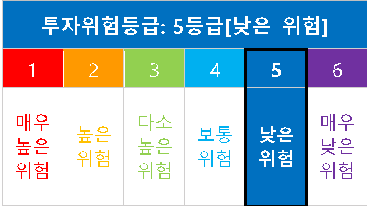


--- imageFile1.png ---


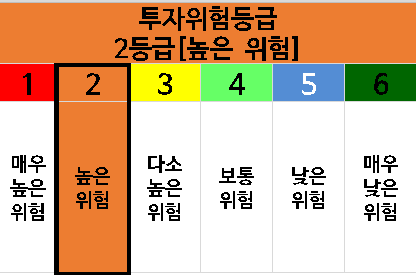

In [13]:
# 이미지 인라인 표시 (최대 5개)
for img in img_files[:5]:
    print(f"\n--- {img.name} ---")
    display(IPImage(filename=str(img), width=400))

## 9. Hybrid HTML 출력

In [14]:
html_output = OUTPUT_DIR / "hybrid_html"
html_output.mkdir(parents=True, exist_ok=True)

opendataloader_pdf.convert(
    input_path=PDF_PATH,
    output_dir=str(html_output),
    format="html",
    hybrid_mode="auto",
    **HYBRID_OPTS,
)

html_files = list(html_output.rglob("*.html"))
if html_files:
    html_text = html_files[0].read_text(encoding="utf-8")
    print(f"HTML: {html_files[0].name} ({len(html_text):,} chars)")
    display(HTML(html_text[:5000]))
else:
    print("HTML 파일이 없습니다.")

Mar 24, 2026 7:19:18 AM org.opendataloader.pdf.processors.DocumentProcessor preprocessing
INFO: File name: /tmp/opendataloader_test/R3_A0000Y0_001.pdf
Mar 24, 2026 7:19:19 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Number of pages: 4
Mar 24, 2026 7:19:19 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Author: 조현주
Mar 24, 2026 7:19:19 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Title: 증 권[일괄] 신고서
Mar 24, 2026 7:19:19 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Creation date: D:20250123164929+09'00'
Mar 24, 2026 7:19:19 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Modification date: D:20250123164929+09'00'
Mar 24, 2026 7:19:19 AM org.opendataloader.pdf.processors.HybridDocumentProcessor processDocument
INFO: Starting hybrid processing for 4 pages
Mar 24, 2026 7:19:20 AM org.apache.fontbox.ttf.CmapSub

## 10. 옵션 비교 테스트

### 10-1. 테이블 방식 비교 (default vs cluster) + Hybrid

In [15]:
for method in ["default", "cluster"]:
    out = OUTPUT_DIR / f"hybrid_table_{method}"
    out.mkdir(parents=True, exist_ok=True)
    
    t0 = time.time()
    opendataloader_pdf.convert(
        input_path=PDF_PATH,
        output_dir=str(out),
        format="json",
        table_method=method,
        hybrid_mode="auto",
        **HYBRID_OPTS,
    )
    elapsed = time.time() - t0
    
    jf = list(out.rglob("*.json"))
    if jf:
        with open(jf[0], encoding="utf-8") as f:
            d = json.load(f)
        all_elems = collect_elements(d)
        tbl = [e for e in all_elems if e.get("type") == "table"]
        print(f"[table_method={method}] 요소: {len(all_elems)}, 테이블: {len(tbl)}, {elapsed:.1f}초")
    else:
        print(f"[table_method={method}] 결과 없음")

Mar 24, 2026 7:22:58 AM org.opendataloader.pdf.processors.DocumentProcessor preprocessing
INFO: File name: /tmp/opendataloader_test/R3_A0000Y0_001.pdf
Mar 24, 2026 7:22:59 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Number of pages: 4
Mar 24, 2026 7:22:59 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Author: 조현주
Mar 24, 2026 7:22:59 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Title: 증 권[일괄] 신고서
Mar 24, 2026 7:22:59 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Creation date: D:20250123164929+09'00'
Mar 24, 2026 7:22:59 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Modification date: D:20250123164929+09'00'
Mar 24, 2026 7:22:59 AM org.opendataloader.pdf.processors.HybridDocumentProcessor processDocument
INFO: Starting hybrid processing for 4 pages
Mar 24, 2026 7:23:00 AM org.apache.fontbox.ttf.CmapSub

### 10-2. Tagged PDF + Hybrid

In [16]:
struct_output = OUTPUT_DIR / "hybrid_struct_tree"
struct_output.mkdir(parents=True, exist_ok=True)

opendataloader_pdf.convert(
    input_path=PDF_PATH,
    output_dir=str(struct_output),
    format="markdown",
    use_struct_tree=True,
    hybrid_mode="auto",
    **HYBRID_OPTS,
)

struct_md = list(struct_output.rglob("*.md"))
if struct_md:
    text = struct_md[0].read_text(encoding="utf-8")
    print(f"[use_struct_tree + hybrid] {len(text):,} chars")
    print(text[:2000])
else:
    print("결과 없음")

Mar 24, 2026 7:30:17 AM org.opendataloader.pdf.processors.DocumentProcessor preprocessing
INFO: File name: /tmp/opendataloader_test/R3_A0000Y0_001.pdf
Mar 24, 2026 7:30:18 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Number of pages: 4
Mar 24, 2026 7:30:18 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Author: 조현주
Mar 24, 2026 7:30:18 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Title: 증 권[일괄] 신고서
Mar 24, 2026 7:30:18 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Creation date: D:20250123164929+09'00'
Mar 24, 2026 7:30:18 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Modification date: D:20250123164929+09'00'
Mar 24, 2026 7:30:19 AM org.opendataloader.pdf.markdown.MarkdownGenerator writeToMarkdown
INFO: Created output_opendataloader/hybrid_struct_tree/R3_A0000Y0_001.md
[use_struct_tree + hybrid] 7,810 c

### 10-3. 페이지 구분자 + 특정 페이지

In [17]:
pages_output = OUTPUT_DIR / "hybrid_pages"
pages_output.mkdir(parents=True, exist_ok=True)

opendataloader_pdf.convert(
    input_path=PDF_PATH,
    output_dir=str(pages_output),
    format="markdown",
    pages="1-3",
    markdown_page_separator="\n\n---\n<!-- Page %page-number% -->\n\n",
    hybrid_mode="full",
    **HYBRID_OPTS,
)

md = list(pages_output.rglob("*.md"))
if md:
    text = md[0].read_text(encoding="utf-8")
    print(f"페이지 1-3 추출 ({len(text):,} chars):")
    print(text[:3000])
else:
    print("결과 없음")

Mar 24, 2026 7:30:19 AM org.opendataloader.pdf.processors.DocumentProcessor preprocessing
INFO: File name: /tmp/opendataloader_test/R3_A0000Y0_001.pdf
Mar 24, 2026 7:30:20 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Number of pages: 4
Mar 24, 2026 7:30:20 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Author: 조현주
Mar 24, 2026 7:30:20 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Title: 증 권[일괄] 신고서
Mar 24, 2026 7:30:20 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Creation date: D:20250123164929+09'00'
Mar 24, 2026 7:30:20 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Modification date: D:20250123164929+09'00'
Mar 24, 2026 7:30:20 AM org.opendataloader.pdf.processors.HybridDocumentProcessor processDocument
INFO: Starting hybrid processing for 4 pages
Mar 24, 2026 7:30:21 AM org.apache.fontbox.ttf.CmapSub

### 10-4. 전체 포맷 한번에 (Hybrid)

In [18]:
all_output = OUTPUT_DIR / "hybrid_all_formats"
all_output.mkdir(parents=True, exist_ok=True)

opendataloader_pdf.convert(
    input_path=PDF_PATH,
    output_dir=str(all_output),
    format="json,markdown,html,text",
    image_output="external",
    hybrid_mode="auto",
    **HYBRID_OPTS,
)

print("출력 파일 목록:")
for f in sorted(all_output.rglob("*")):
    if f.is_file():
        print(f"  {str(f.relative_to(all_output)):<50} {f.stat().st_size:>10,} bytes")

Mar 24, 2026 7:33:59 AM org.opendataloader.pdf.processors.DocumentProcessor preprocessing
INFO: File name: /tmp/opendataloader_test/R3_A0000Y0_001.pdf
Mar 24, 2026 7:34:00 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Number of pages: 4
Mar 24, 2026 7:34:00 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Author: 조현주
Mar 24, 2026 7:34:00 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Title: 증 권[일괄] 신고서
Mar 24, 2026 7:34:00 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Creation date: D:20250123164929+09'00'
Mar 24, 2026 7:34:00 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Modification date: D:20250123164929+09'00'
Mar 24, 2026 7:34:00 AM org.opendataloader.pdf.processors.HybridDocumentProcessor processDocument
INFO: Starting hybrid processing for 4 pages
Mar 24, 2026 7:34:01 AM org.apache.fontbox.ttf.CmapSub

## 11. Bounding Box 시각화

Hybrid JSON 결과의 bbox를 PDF 페이지 이미지 위에 그립니다.
- **빨강**: 테이블 (table)
- **초록**: 이미지 (image)
- **파랑**: 단락 (paragraph)
- **보라**: 제목 (heading)
- **주황**: 리스트 (list)

시각화할 요소: 66개
  paragraph        47개  (파랑)
  heading          10개  (보라)
  table             6개  (빨강)
  list              2개  (주황)
  image             1개  (초록)

PDF: /tmp/opendataloader_test/R3_A0000Y0_001.pdf

페이지 1


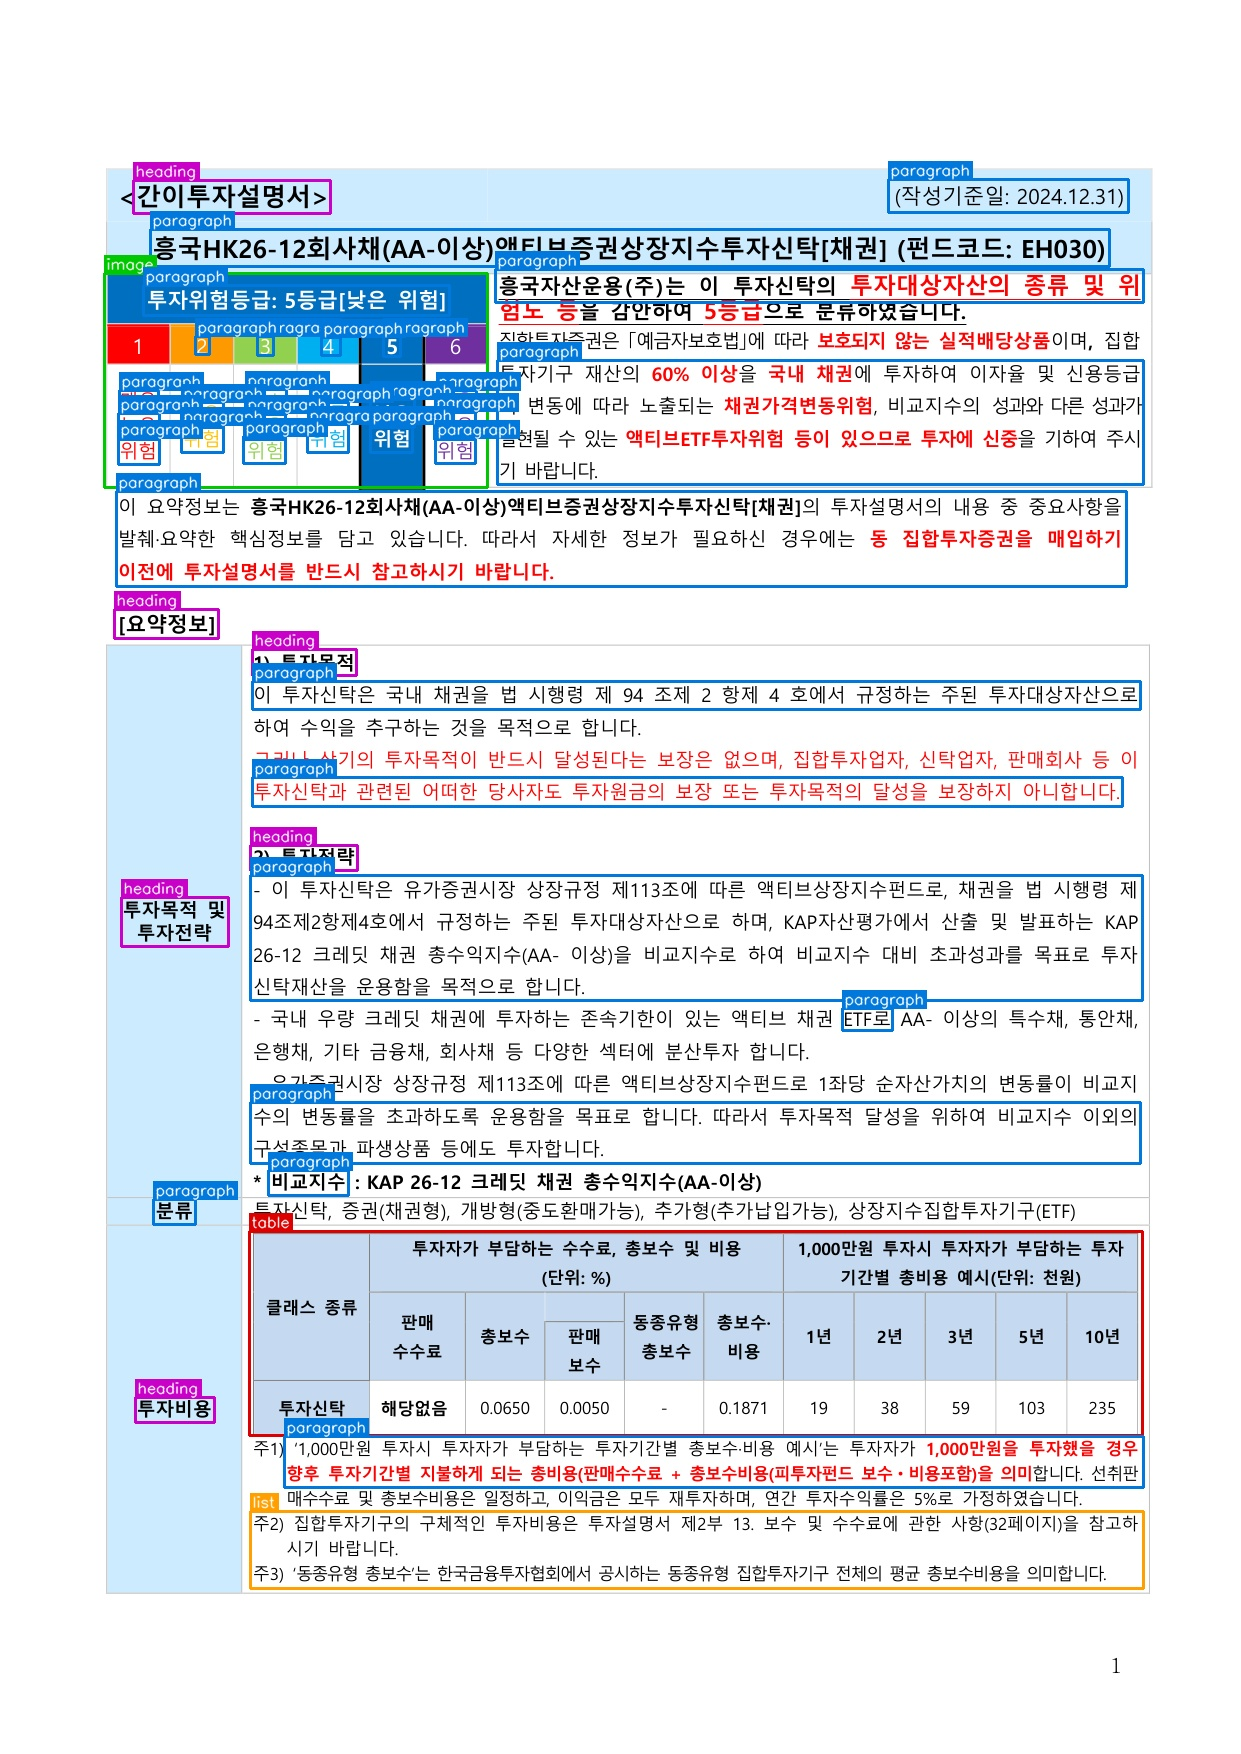


페이지 2


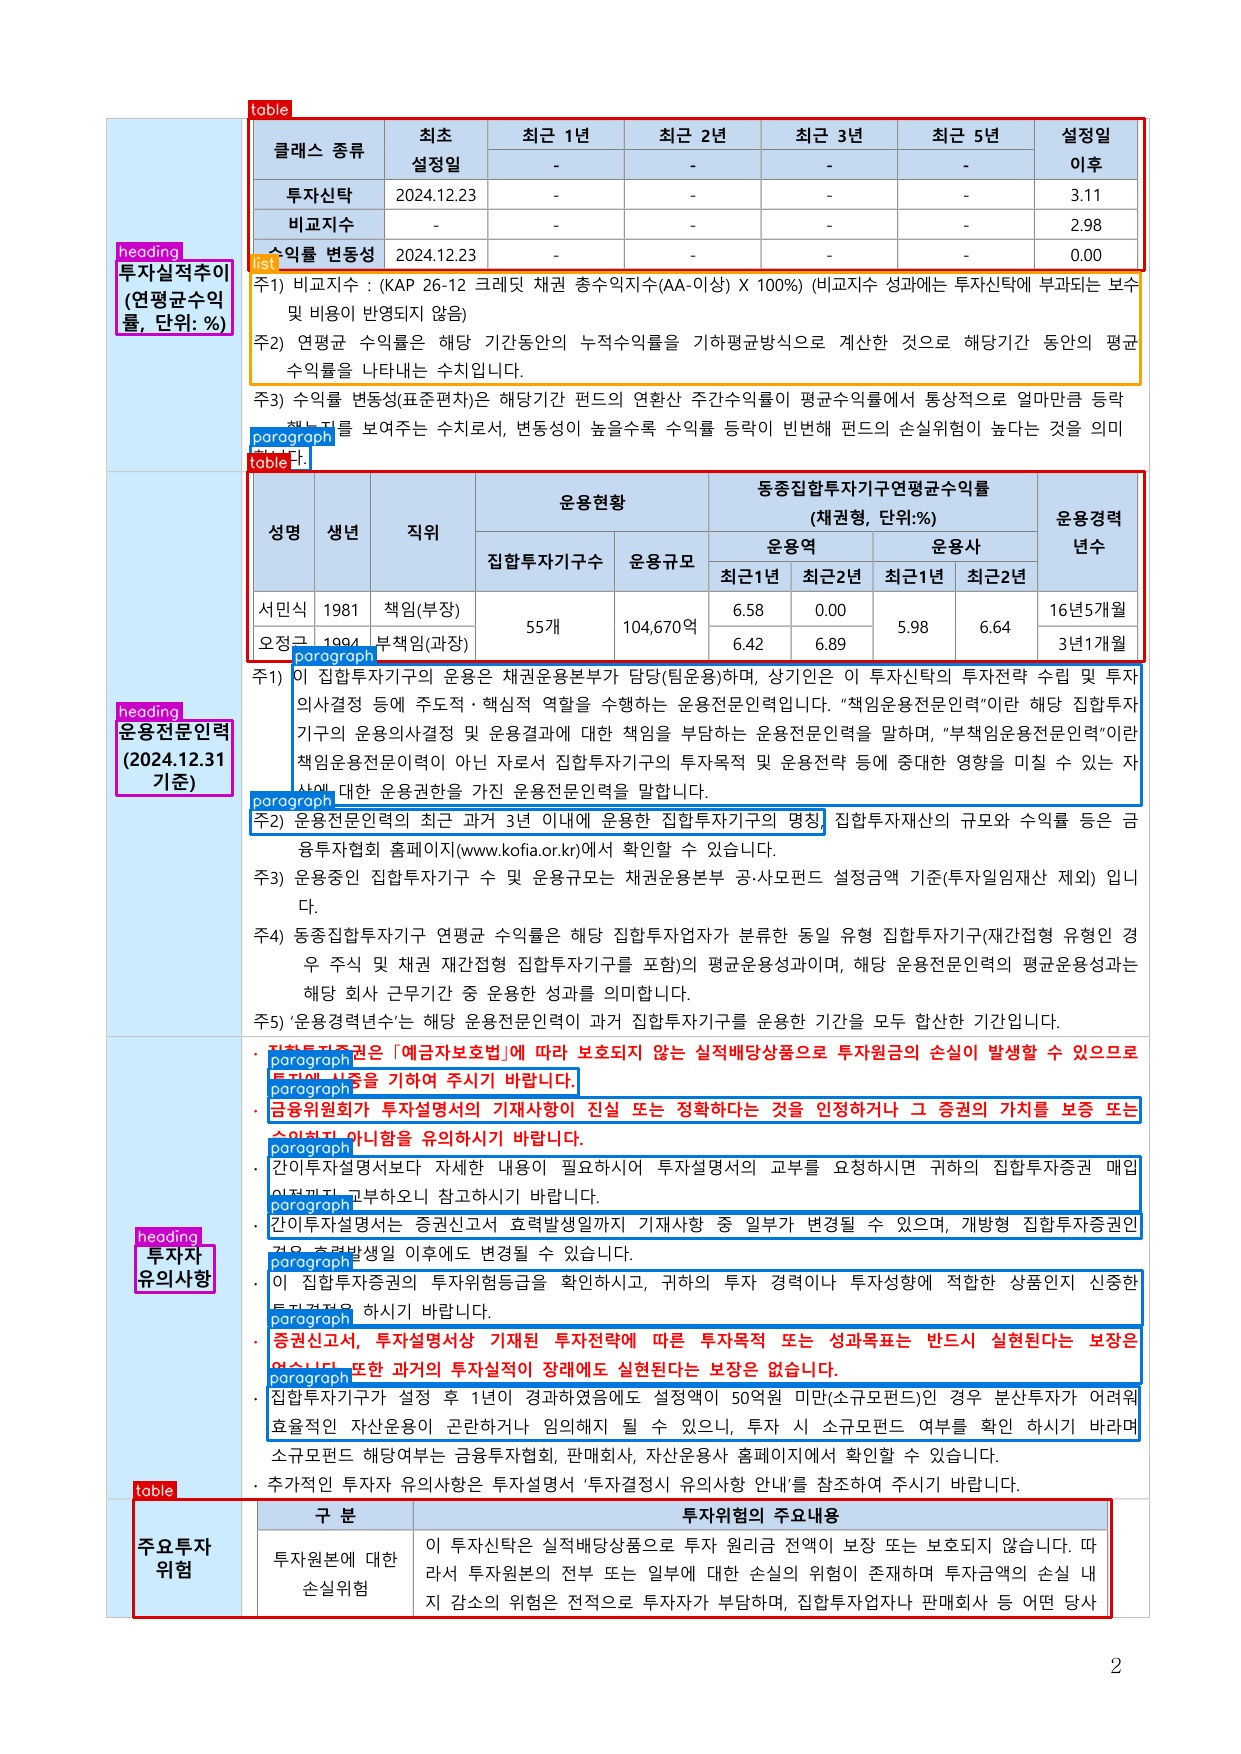


페이지 3


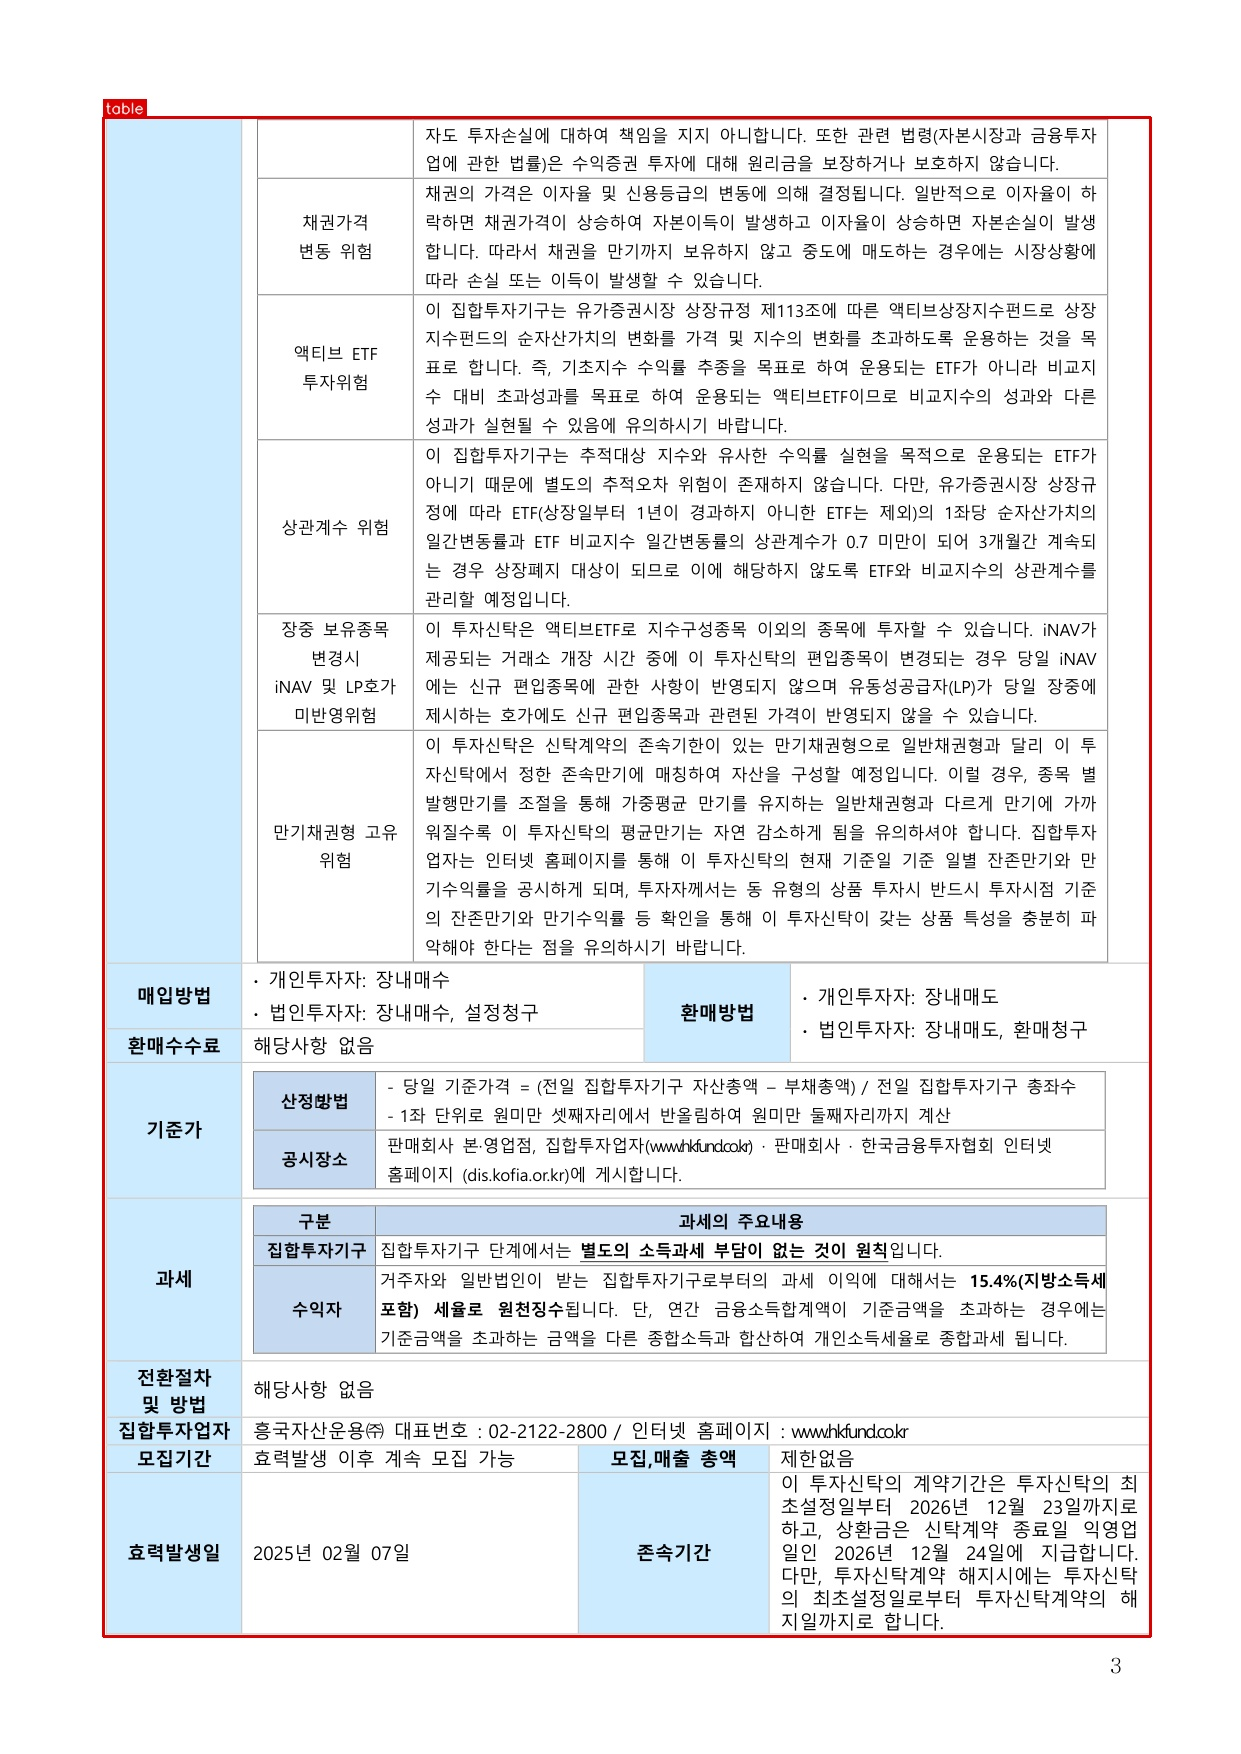


페이지 4


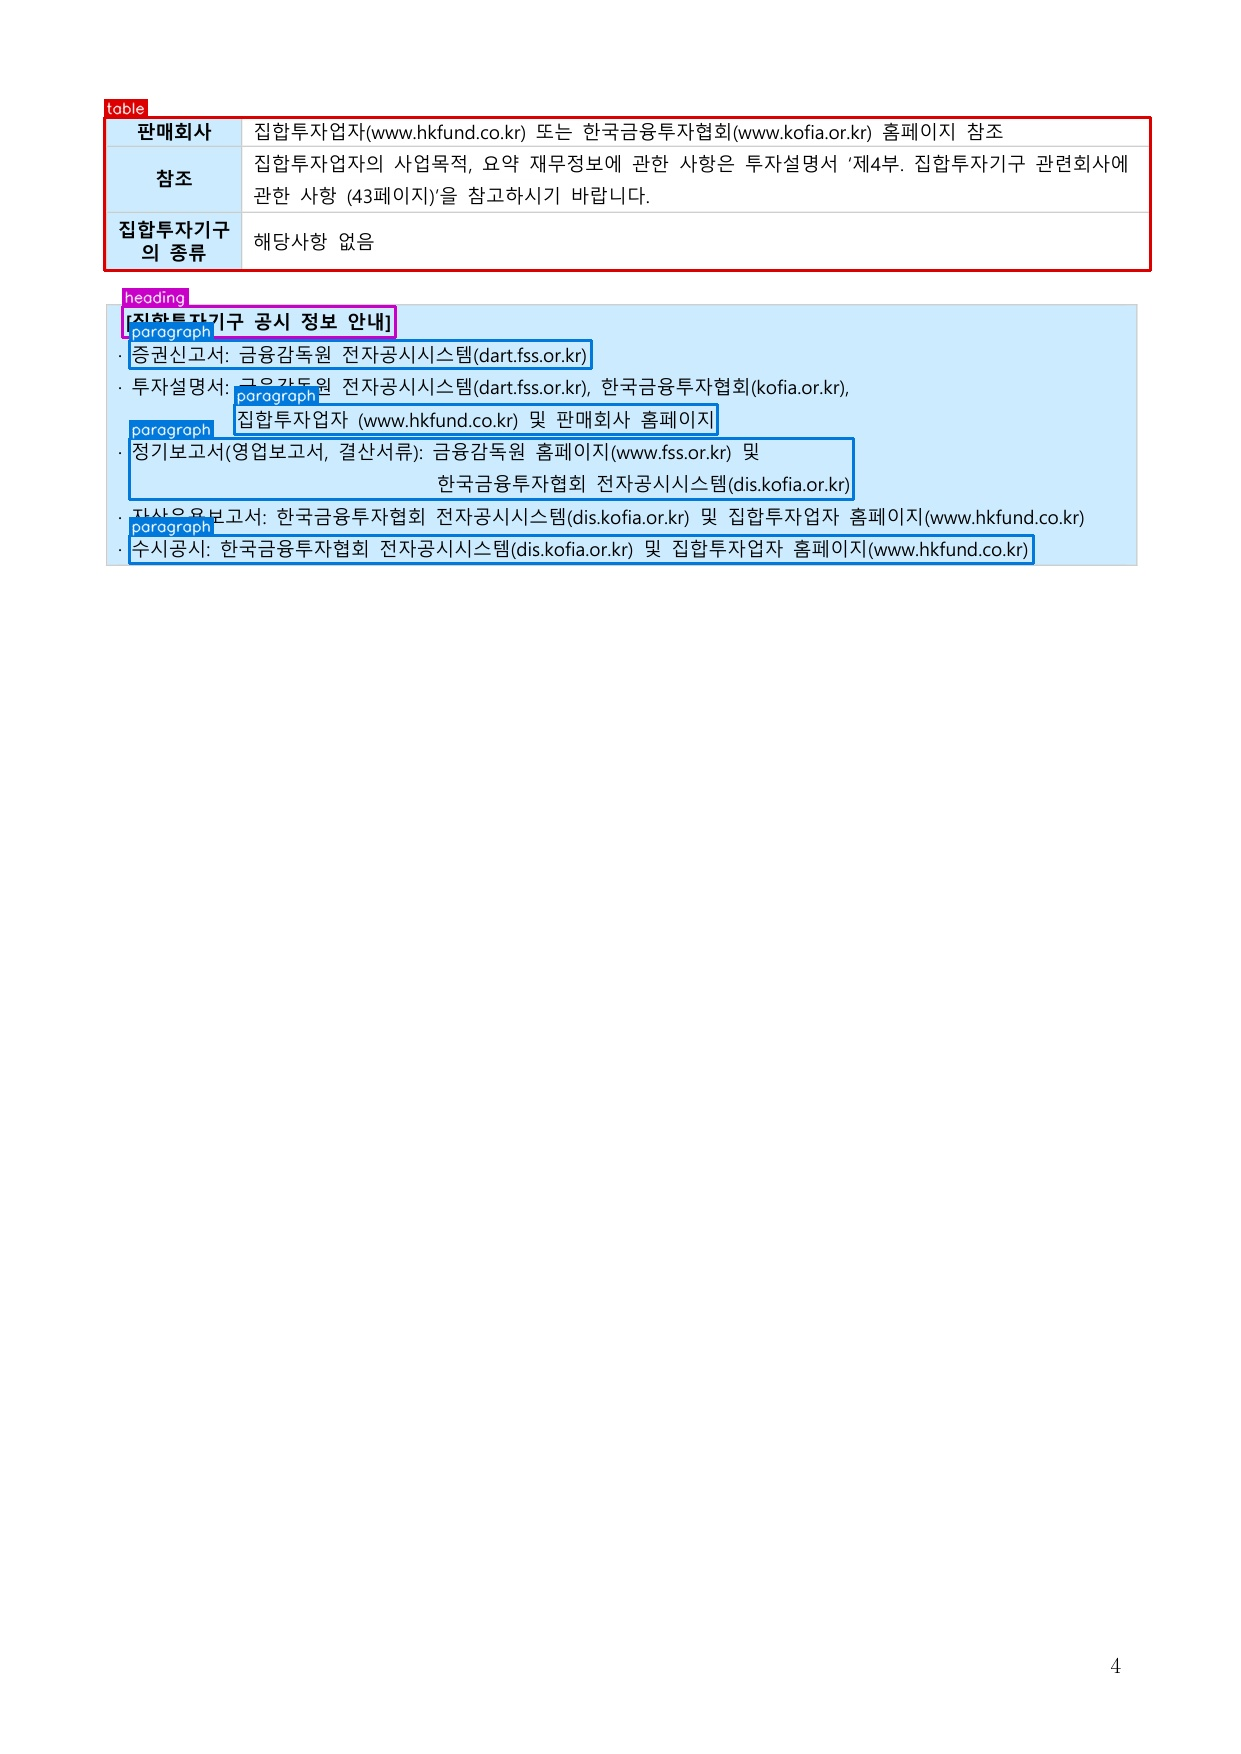


bbox 이미지 저장: output_opendataloader/bbox/


In [20]:
import fitz  # pymupdf
import cv2
import numpy as np
from collections import defaultdict

# 타입별 색상 (BGR)
TYPE_COLORS = {
    "table":     (0, 0, 220),     # 빨강
    "image":     (0, 200, 0),     # 초록
    "paragraph": (220, 120, 0),   # 파랑
    "heading":   (200, 0, 200),   # 보라
    "list":      (0, 160, 255),   # 주황
}
DEFAULT_COLOR = (128, 128, 128)   # 회색

# 시각화할 요소 타입 (table cell 등 하위 요소는 제외)
DRAW_TYPES = {"table", "image", "paragraph", "heading", "list"}


def collect_top_elements(node):
    """JSON 트리에서 최상위 요소만 수집 (table의 하위 row/cell은 제외)"""
    results = []
    if isinstance(node, dict):
        if node.get("type") in DRAW_TYPES and "bounding box" in node:
            results.append(node)
            if node.get("type") == "table":
                return results
        for child in node.get("kids", []):
            results.extend(collect_top_elements(child))
    elif isinstance(node, list):
        for item in node:
            results.extend(collect_top_elements(item))
    return results


def draw_bboxes_on_pdf(pdf_path, json_data, dpi=150):
    """PDF 페이지 이미지에 JSON bbox를 그려서 반환"""
    elements = collect_top_elements(json_data)
    page_elements = defaultdict(list)
    for e in elements:
        page_no = e.get("page number", 0)
        page_elements[page_no].append(e)

    doc = fitz.open(pdf_path)
    result_images = {}

    for page_idx in range(len(doc)):
        page_no = page_idx + 1
        page = doc[page_idx]
        page_rect = page.rect

        mat = fitz.Matrix(dpi / 72, dpi / 72)
        pix = page.get_pixmap(matrix=mat)
        img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.h, pix.w, pix.n)
        if pix.n == 4:
            img = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

        scale_x = pix.w / page_rect.width
        scale_y = pix.h / page_rect.height

        elems = page_elements.get(page_no, [])
        for e in elems:
            bbox = e["bounding box"]
            etype = e.get("type", "unknown")
            color = TYPE_COLORS.get(etype, DEFAULT_COLOR)

            # PDF 좌표 (좌하단 원점) → 좌상단 원점으로 변환
            x1 = bbox[0]
            y1 = page_rect.height - bbox[3]
            x2 = bbox[2]
            y2 = page_rect.height - bbox[1]

            px1, py1 = int(x1 * scale_x), int(y1 * scale_y)
            px2, py2 = int(x2 * scale_x), int(y2 * scale_y)

            cv2.rectangle(img, (px1, py1), (px2, py2), color, 2)

            label = etype
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(img, (px1, py1 - th - 6), (px1 + tw + 4, py1), color, -1)
            cv2.putText(img, label, (px1 + 2, py1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

        result_images[page_no] = img

    doc.close()
    return result_images


# --- bbox 시각화 실행 ---
json_path = list(hybrid_output.rglob(f"{pdf_name}.json"))
if not json_path:
    json_path = list(hybrid_full_output.rglob("*.json"))

if json_path:
    with open(json_path[0], encoding="utf-8") as f:
        json_data = json.load(f)

    # 요소 통계
    elements = collect_top_elements(json_data)
    from collections import Counter
    type_stats = Counter(e["type"] for e in elements)
    print(f"시각화할 요소: {len(elements)}개")
    for t, c in type_stats.most_common():
        color_name = {
            "table": "빨강", "image": "초록", "paragraph": "파랑",
            "heading": "보라", "list": "주황",
        }.get(t, "회색")
        print(f"  {t:<15} {c:>3}개  ({color_name})")

    # bbox 그리기
    print(f"\nPDF: {PDF_PATH}")
    bbox_images = draw_bboxes_on_pdf(PDF_PATH, json_data, dpi=150)

    # 페이지별 표시
    bbox_dir = OUTPUT_DIR / "bbox"
    bbox_dir.mkdir(parents=True, exist_ok=True)

    for page_no, img in sorted(bbox_images.items()):
        out_path = bbox_dir / f"{pdf_name}_page{page_no:03d}_bbox.jpg"
        cv2.imwrite(str(out_path), img, [cv2.IMWRITE_JPEG_QUALITY, 90])

        print(f"\n{'='*60}")
        print(f"페이지 {page_no}")
        print(f"{'='*60}")
        _, jpg_buf = cv2.imencode(".jpg", img)
        display(IPImage(data=jpg_buf.tobytes(), width=800))

    print(f"\nbbox 이미지 저장: {bbox_dir}/")
else:
    print("JSON 파일이 없습니다. 먼저 Hybrid 변환을 실행하세요.")

## 11. Bounding Box 시각화

Hybrid JSON 결과의 bbox를 PDF 페이지 이미지 위에 그립니다.
- **빨강**: 테이블 (table)
- **초록**: 이미지 (image)
- **파랑**: 단락 (paragraph)
- **보라**: 제목 (heading)
- **주황**: 리스트 (list)

## 12. 정리

In [ ]:
# Hybrid 백엔드 서버 종료 (필요시)
if 'hybrid_proc' in dir() and hybrid_proc.poll() is None:
    hybrid_proc.terminate()
    hybrid_proc.wait(timeout=10)
    print("Hybrid 백엔드 서버 종료 완료")
else:
    print("종료할 Hybrid 프로세스가 없습니다.")
    print("(별도 터미널에서 실행한 경우 직접 종료하세요)")